In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
import pandas as pd

pd.options.display.float_format = '{:.2f}'.format

qSales = pd.read_csv('qSales_2024 (1).csv')

display(qSales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
0,1690,2001-03-31,2001,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q1,2001Q2,1431.00,A
1,1690,2001-06-30,2001,3,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q2,2001Q3,1475.00,A
2,1690,2001-09-30,2001,4,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q3,2001Q4,1450.00,A
3,1690,2001-12-31,2002,1,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2001Q4,2002Q1,1375.00,A
4,1690,2002-03-31,2002,2,9,INDL,C,D,STD,AAPL,APPLE INC,USD,2002Q1,2002Q2,1495.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
272,102450,2022-12-31,2022,3,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2022Q4,2022Q3,5280.78,A
273,102450,2023-03-31,2022,4,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q1,2022Q4,2226.88,A
274,102450,2023-06-30,2023,1,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q2,2023Q1,3190.81,A
275,102450,2023-09-30,2023,2,3,INDL,C,D,STD,NTDOY,NINTENDO CO LTD,USD,2023Q3,2023Q2,2140.04,A


In [ ]:
qSales['datadate'] = pd.to_datetime(qSales['datadate'])

In [ ]:
target_sales = qSales.loc[qSales['tic']=='TGT']

display(target_sales)

,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A


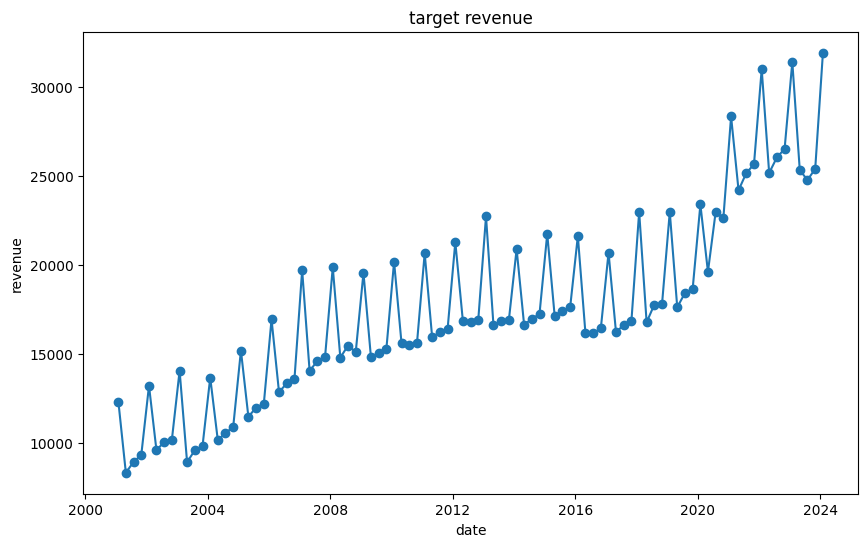

In [ ]:
plt.figure(figsize=(10,6))

plt.title('target revenue')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'],target_sales['saleq'],marker='o')

In [ ]:
target_sales['time'] = range(1, len(target_sales) + 1)
#be sure to add the + 1

display(target_sales)

/tmp/ipykernel_944/3506376388.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['time'] = range(1, len(target_sales) + 1)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92


In [ ]:
# Q4 (holdiay)
target_sales['holiday_dv'] = np.where(target_sales['fqtr']==4,1,0)

# Q1 fiscal quarter (after holiday)
target_sales['postholiday_dv'] = np.where(target_sales['fqtr']==1,1,0)

display(target_sales)

/tmp/ipykernel_944/3839153680.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['holiday_dv'] = np.where(target_sales['fqtr']==4,1,0)
/tmp/ipykernel_944/3839153680.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['postholiday_dv'] = np.where(target_sales['fqtr']==1,1,0)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,postholiday_dv
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,1
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,0
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,1
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,0
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,0


In [ ]:
dt4training = target_sales[:int(0.75 * len(target_sales))] #takes the first 75% of rows
dt4testing = target_sales[int(0.75 * len(target_sales)):] #takes the last 25% of rows


In [ ]:
y = dt4training.loc[:,'saleq']
x = dt4training.loc[:,['time','holiday_dv','postholiday_dv']]
x = sm.add_constant(x)

model_target = sm.OLS(y,x).fit()

model_target.params

,0
const,9399.40
time,139.15
holiday_dv,4472.62
postholiday_dv,-232.80


In [ ]:
x_test = dt4testing.loc[:,['time','holiday_dv','postholiday_dv']]
x_test = sm.add_constant(x_test)

model_target.get_prediction(x_test).summary_frame(alpha=0.2)

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
161,18907.24,392.63,18398.89,19415.59,17266.72,20547.76
162,19279.19,331.02,18850.61,19707.77,17661.61,20896.77
163,19418.34,336.75,18982.35,19854.34,17798.78,21037.91
164,24030.11,396.58,23516.66,24543.57,22388.00,25672.22
165,19463.85,412.67,18929.56,19998.14,17815.11,21112.59
166,19835.80,354.26,19377.14,20294.47,18209.99,21461.61
167,19974.95,360.20,19508.59,20441.31,18346.96,21602.95
168,24586.72,417.44,24046.25,25127.19,22935.97,26237.48
169,20020.46,433.74,19458.89,20582.03,18362.67,21678.24
170,20392.41,378.31,19902.60,20882.22,18757.54,22027.28


In [ ]:
x_full = target_sales.loc[:,['time','holiday_dv','postholiday_dv']]
x_full = sm.add_constant(x_full)

target_sales['predicted_revenue'] = model_target.predict(x_full)

display(target_sales)

/tmp/ipykernel_944/3085917803.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  target_sales['predicted_revenue'] = model_target.predict(x_full)


,gvkey,datadate,fyearq,fqtr,fyr,indfmt,consol,popsrc,datafmt,tic,conm,curcdq,datacqtr,datafqtr,saleq,costat,time,holiday_dv,postholiday_dv,predicted_revenue
92,3813,2001-01-31,2000,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2000Q4,2000Q4,12324.00,A,1,1,0,14011.16
93,3813,2001-04-30,2001,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q1,2001Q1,8334.00,A,2,0,1,9444.90
94,3813,2001-07-31,2001,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q2,2001Q2,8941.00,A,3,0,0,9816.85
95,3813,2001-10-31,2001,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q3,2001Q3,9331.00,A,4,0,0,9956.00
96,3813,2002-01-31,2001,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2001Q4,2001Q4,13220.00,A,5,1,0,14567.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180,3813,2023-01-31,2022,4,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2022Q4,2022Q4,31395.00,A,89,1,0,26256.55
181,3813,2023-04-30,2023,1,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q1,2023Q1,25322.00,A,90,0,1,21690.28
182,3813,2023-07-31,2023,2,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q2,2023Q2,24773.00,A,91,0,0,22062.23
183,3813,2023-10-31,2023,3,1,INDL,C,D,STD,TGT,TARGET CORP,USD,2023Q3,2023Q3,25398.00,A,92,0,0,22201.39


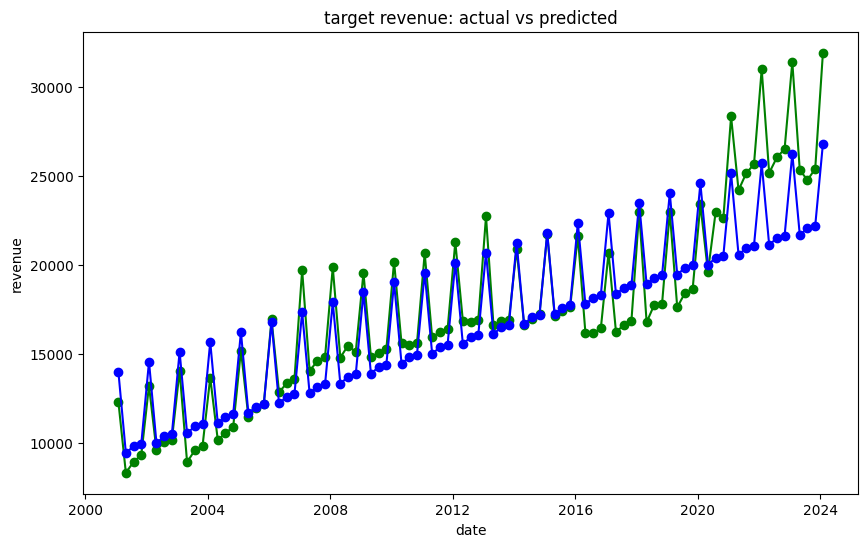

In [ ]:
plt.figure(figsize=(10,6))

plt.title('target revenue: actual vs predicted')

plt.xlabel('date')
plt.ylabel('revenue')

plt.plot(target_sales['datadate'],target_sales['saleq'],marker='o',color='green')
plt.plot(target_sales['datadate'],target_sales['predicted_revenue'],marker='o',color='blue')

In [ ]:
model_target.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  saleq   R-squared:                       0.895
Model:                            OLS   Adj. R-squared:                  0.891
Method:                 Least Squares   F-statistic:                     185.4
Date:                Sat, 25 Jul 2026   Prob (F-statistic):           8.54e-32
Time:                        03:03:52   Log-Likelihood:                -585.33
No. Observations:                  69   AIC:                             1179.
Df Residuals:                      65   BIC:                             1188.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const           9399.3953    331.025     28.395      0.000    8738.294    1.01e+04
time             139.1521      7.285     19.100      0.000     124.602     153.702
holiday_dv      4472.6153    351.186     12.736      0.000    3771.249    5173.982
postholiday_dv  -232.8013    358.023     -0.650      0.518    -947.823     482.221
==============================================================================
Omnibus:                        6.079   Durbin-Watson:                   0.202
Prob(Omnibus):                  0.048   Jarque-Bera (JB):                2.803
Skew:                          -0.202   Prob(JB):                        0.246
Kurtosis:                       2.099   Cond. No.                         127.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

To: Chapman Wealth Management

Re: Target Revenue Analysis

From: hsthomas@uwaterloo.ca


Targets revenue shows an upward trend that is cyclical due to holiday spikes which is acurately predicted by the regression model until recent quarters where revenue is understated.

We built a regression model predicting Target's quarterly revenue using revenue as dependent variable and time, dummy variable holiday (q4), dummy variable post holiday (q1) as independent variables. The model was trained on the first 75% of the historical data and tested on the remaining 25%.


Key Findings
*  The regression model shows 89.5% of variation in Target's revenue
* Holiday quarters have a revenue significantly above non holiday quarters (4472.62 million)
* Post holiday quarters showed a slight decline in revenue as well
* Model underpredicts revenue in recent years


Recommendation
* Target’s revenue has shown a strong upward trend showing consistent growth
* The regression model understating recent revenue shows that Target is growing at a rapid pace
* Holiday periods consistently have a significant impact on increasing revenue
* It is recommended to build a new model with  factors that consider Targets changing trend for future revenue forcasts
* Targets revenue generation appears positive but additional external factors should also be considered before investing

